In [1]:
import numpy as np
from tensorflow.keras.models import load_model
import hls4ml
from qkeras.utils import _add_supported_quantized_objects

2026-05-28 12:21:02.188701: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 12:21:02.754431: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Matplotlib created a temporary config/cache directory at /tmp/matplotlib-bkrpqm_i because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support 

/opt/conda/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
resolution = 150

#model_orig = load_model(f'unpruned_model_{resolution}.h5')
co = {}
_add_supported_quantized_objects(co)
X_total = np.load(f"../Data/X_Data_Bank_{resolution}.npy")
Y_total = np.load(f"../Data/Y_Data_Bank_{resolution}.npy")
X_test = X_total[1500:2000,:,:]
Y_test = Y_total[1500:2000,:,:]
NUM_EVENTS = 500
TIME_STEPS = int(12000/resolution)
base_name ="no_opt_150_16"
original_model = load_model(f"../Models/quantized_model_{base_name}.h5", custom_objects=co)
#precisions = ["<20,2>","<20,4>","<20,6>","<20,8>","<20,10>","<20,12>"]
precisions = ["<10,10>","<12,10>","<14,10>","<16,10>","<18,10>","<20,10>"]

2026-05-28 12:21:09.082703: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


In [3]:
y_predictions = []
Y_test_reduced = Y_test
for i in range(NUM_EVENTS):
    for j in range(TIME_STEPS):
        if Y_test_reduced[i][j]!=0:
            Y_test_reduced[i][j]=1
            
for i in range(len(precisions)):
    hls_config = hls4ml.utils.config_from_keras_model(
        original_model,
        granularity='name',
        backend='Vitis',
        default_precision=f'ap_fixed{precisions[i]}'
    )
    hls_model = hls4ml.converters.convert_from_keras_model(
        original_model,
        hls_config=hls_config,
        backend='Vitis',
        output_dir=f'../HLS_models/{base_name}{precisions[i]}',
        part='xcu250-figd2104-2L-e',
        io_type='io_stream',
    )
    hls_model.compile()
    new_y_predict = hls_model.predict(X_test)
    y_predictions.append(new_y_predict)

Interpreting Sequential
Topology:
Layer name: input_6, layer type: InputLayer, input shapes: [[None, 80, 1]], output shape: [None, 80, 1]
Layer name: q_conv1d_20, layer type: QConv1D, input shapes: [[None, 80, 1]], output shape: [None, 80, 16]
Layer name: q_activation_20, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_21, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_activation_21, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_22, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_activation_22, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_23, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 1]
Layer name: q_activation_23, layer type: HardActivation, input shapes: [[None, 80, 1]], output

Done
Interpreting Sequential
Topology:
Layer name: input_6, layer type: InputLayer, input shapes: [[None, 80, 1]], output shape: [None, 80, 1]
Layer name: q_conv1d_20, layer type: QConv1D, input shapes: [[None, 80, 1]], output shape: [None, 80, 16]
Layer name: q_activation_20, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_21, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_activation_21, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_22, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_activation_22, layer type: Activation, input shapes: [[None, 80, 16]], output shape: [None, 80, 16]
Layer name: q_conv1d_23, layer type: QConv1D, input shapes: [[None, 80, 16]], output shape: [None, 80, 1]
Layer name: q_activation_23, layer type: HardActivation, input shapes: [[None, 80, 1]], o

Done


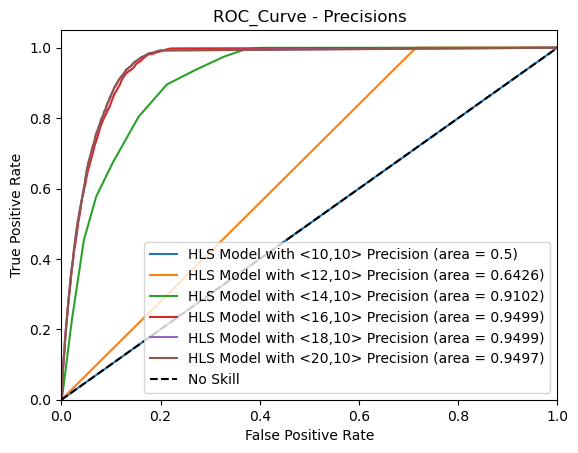

In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
def plotROC_Comparison(y_test_reduced, listYs, filters):
    plt.figure()  
    for Y_predict_index in range(len(listYs)):
        Y_predict = listYs[Y_predict_index]
        fpr, tpr, thresholds = roc_curve(Y_test_reduced.flatten(), Y_predict.flatten()) 
        roc_auc = auc(fpr, tpr)
        roc_auc = int(roc_auc * 10000) / 10000
        plt.plot(fpr, tpr, label=f'HLS Model with {filters[Y_predict_index]} Precision (area = {roc_auc})')
    plt.title("ROC_Curve - Precisions")
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    #plt.savefig("ROC_Curve_Precisions_2",pad_inches=0.1)
    plt.show()
        
#plotROC_Comparison(Y_test_reduced,y_predict_hls, y_predict_hls1, y_predict_final)
plotROC_Comparison(Y_test_reduced,y_predictions, precisions)
def findROCVal(Y_test_reduced, Y_predict): 
    fpr, tpr, thresholds = roc_curve(Y_test_reduced.flatten(), Y_predict.flatten()) 
    roc_auc = auc(fpr, tpr)
    return roc_auc

#### 